# LightGBM Model for Delinquency Prediction

Uses the **top 50 selected features** from the comprehensive feature selection pipeline.

- Train / Validation / Test split (60/20/20)
- LightGBM gradient boosting classifier
- Handles class imbalance with `scale_pos_weight`
- Records training time, scoring time, and model performance

In [ ]:
import sys
import pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from scripts.model_data import load_and_split, save_sorted_features

## 1. Load Data & Selected Features

In [ ]:
# ── Configuration ────────────────────────────────────────────────
N_FEATURES = 50  # ← change this to use a different number of top-ranked features

# Write output/sorted_features.csv (columns ordered by rank) once
save_sorted_features()

Total consumers: 12900
Selected features: 100
Delinquency rate: 8.86%


## 2. Prepare Data & Train/Val/Test Split

In [ ]:
# Load features and perform 60/20/20 stratified split
X_train, X_val, X_test, y_train, y_val, y_test, available_features, features_df = \
    load_and_split(n_features=N_FEATURES)

Features used: 100
Samples: 10317
Class distribution: 0=9403, 1=914

Train: 6190 (8.85% positive)
Val:   2063 (8.87% positive)
Test:  2064 (8.87% positive)


## 3. Train LightGBM Model

In [ ]:
# Class imbalance weight
n_neg = np.sum(y_train == 0)
n_pos = np.sum(y_train == 1)
scale_pos_weight = n_neg / n_pos
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

# Create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train, feature_name=available_features)
val_data = lgb.Dataset(X_val, label=y_val, feature_name=available_features, reference=train_data)

# LightGBM parameters
params = {
    'objective': 'binary',
    'metric': ['auc', 'binary_logloss'],
    'boosting_type': 'gbdt',
    'scale_pos_weight': scale_pos_weight,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'verbose': -1,
    'seed': 42,
}

# Train with early stopping
print('\nTraining LightGBM...')
training_start_time = time.time()

evals_result = {}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=50),
    lgb.record_evaluation(evals_result),
]

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val'],
    callbacks=callbacks,
)

training_end_time = time.time()
training_time = training_end_time - training_start_time

print(f'\nTraining completed in {training_time:.2f}s')
print(f'Best iteration: {model.best_iteration}')
print(f'Best val AUC: {model.best_score["val"]["auc"]:.4f}')


scale_pos_weight: 10.30

Training LightGBM...
Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.982167	train's binary_logloss: 0.281446	val's auc: 0.777373	val's binary_logloss: 0.377606
Early stopping, best iteration is:
[2]	train's auc: 0.861825	train's binary_logloss: 0.276205	val's auc: 0.706322	val's binary_logloss: 0.290623

Training completed in 0.94s
Best iteration: 2
Best val AUC: 0.7063


## 5. Evaluation on All Splits

In [ ]:
def evaluate(model, X, y_true, split_name):
    """Evaluate model and print metrics."""
    scoring_start = time.time()
    
    # Predict probabilities
    y_proba = model.predict(X, num_iteration=model.best_iteration)
    
    scoring_time = time.time() - scoring_start
    
    # AUC
    auc = roc_auc_score(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)
    
    # Binary predictions at 0.5 threshold
    y_pred = (y_proba >= 0.5).astype(int)
    
    print(f'\n{"="*50}')
    print(f'{split_name} Results')
    print(f'{"="*50}')
    print(f'ROC-AUC: {auc:.4f}')
    print(f'Average Precision: {ap:.4f}')
    print(f'Scoring Time: {scoring_time:.4f} seconds')
    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=['No DQ', 'DQ']))
    print(f'Confusion Matrix:')
    print(confusion_matrix(y_true, y_pred))
    
    return y_proba, auc, ap, scoring_time

train_preds, train_auc, train_ap, train_time = evaluate(model, X_train, y_train, 'TRAIN')
val_preds, val_auc, val_ap, val_time = evaluate(model, X_val, y_val, 'VALIDATION')
test_preds, test_auc, test_ap, test_time = evaluate(model, X_test, y_test, 'TEST')


TRAIN Results
ROC-AUC: 0.8618
Average Precision: 0.2987
Scoring Time: 0.0000 seconds

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.91      1.00      0.95      5642
          DQ       0.00      0.00      0.00       548

    accuracy                           0.91      6190
   macro avg       0.46      0.50      0.48      6190
weighted avg       0.83      0.91      0.87      6190

Confusion Matrix:
[[5642    0]
 [ 548    0]]

VALIDATION Results
ROC-AUC: 0.7063
Average Precision: 0.1808
Scoring Time: 0.0000 seconds

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.91      1.00      0.95      1880
          DQ       0.00      0.00      0.00       183

    accuracy                           0.91      2063
   macro avg       0.46      0.50      0.48      2063
weighted avg       0.83      0.91      0.87      2063

Confusion Matrix:
[[1880    0]
 [ 183    0]]

TEST Results
ROC-AUC: 0.7176
A

## 6. Precision-Recall Curves

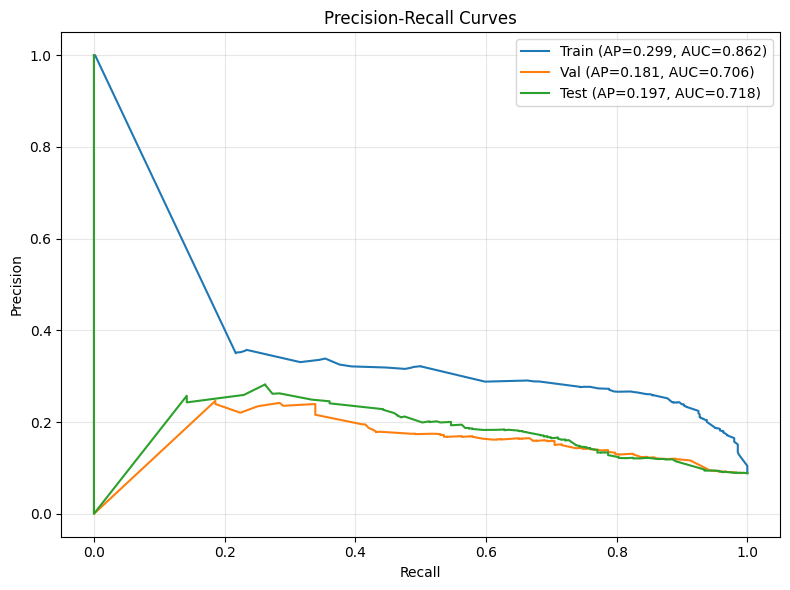

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for preds, targets, name, auc_val in [
    (train_preds, y_train, 'Train', train_auc),
    (val_preds, y_val, 'Val', val_auc),
    (test_preds, y_test, 'Test', test_auc)
]:
    precision, recall, _ = precision_recall_curve(targets, preds)
    ap = average_precision_score(targets, preds)
    ax.plot(recall, precision, label=f'{name} (AP={ap:.3f}, AUC={auc_val:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Summary

In [ ]:
print('LightGBM Model Summary')
print('=' * 50)
print(f'Boosting type: GBDT')
print(f'Num leaves: {params["num_leaves"]}')
print(f'Learning rate: {params["learning_rate"]}')
print(f'Best iteration: {model.best_iteration}')
print(f'Features used: {len(available_features)}')
print(f'')
print(f'Training Time: {training_time:.2f}s ({training_time/60:.2f} min)')
print(f'')
print(f'{"Split":<12} {"ROC-AUC":<12} {"Avg Precision":<16} {"Scoring Time":<14}')
print(f'{"-"*54}')
print(f'{"Train":<12} {train_auc:<12.4f} {train_ap:<16.4f} {train_time:<14.4f}s')
print(f'{"Val":<12} {val_auc:<12.4f} {val_ap:<16.4f} {val_time:<14.4f}s')
print(f'{"Test":<12} {test_auc:<12.4f} {test_ap:<16.4f} {test_time:<14.4f}s')

LightGBM Model Summary
Boosting type: GBDT
Num leaves: 31
Learning rate: 0.05
Best iteration: 2
Features used: 100

Training Time: 0.94s (0.02 min)

Split        ROC-AUC      Avg Precision    Scoring Time  
------------------------------------------------------
Train        0.8618       0.2987           0.0000        s
Val          0.7063       0.1808           0.0000        s
Test         0.7176       0.1967           0.0020        s


---
# LightGBM – All Features

Same setup but using **every available feature** instead of the top-50 selection.

In [ ]:
# ── Use ALL features ─────────────────────────────────────────────
X_train_all, X_val_all, X_test_all, y_train_all, y_val_all, y_test_all, all_feature_cols, _ = \
    load_and_split(use_all=True)

Total features: 217
Samples: 10317
Class distribution: 0=9403, 1=914

Train: 6190 (8.85% positive)
Val:   2063 (8.87% positive)
Test:  2064 (8.87% positive)


In [ ]:
# ── Train LightGBM (all features) ────────────────────────────────
n_neg_all = np.sum(y_train_all == 0)
n_pos_all = np.sum(y_train_all == 1)
scale_pos_weight_all = n_neg_all / n_pos_all
print(f'scale_pos_weight: {scale_pos_weight_all:.2f}')

train_data_all = lgb.Dataset(X_train_all, label=y_train_all, feature_name=all_feature_cols)
val_data_all   = lgb.Dataset(X_val_all,   label=y_val_all,   feature_name=all_feature_cols,
                              reference=train_data_all)

params_all = {
    'objective': 'binary',
    'metric': ['auc', 'binary_logloss'],
    'boosting_type': 'gbdt',
    'scale_pos_weight': scale_pos_weight_all,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'verbose': -1,
    'seed': 42,
}

print('\nTraining LightGBM (all features)...')
train_start_all = time.time()

evals_result_all = {}

model_all = lgb.train(
    params_all,
    train_data_all,
    num_boost_round=1000,
    valid_sets=[train_data_all, val_data_all],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50),
        lgb.record_evaluation(evals_result_all),
    ],
)

training_time_all = time.time() - train_start_all
print(f'\nTraining completed in {training_time_all:.2f}s')
print(f'Best iteration: {model_all.best_iteration}')
print(f'Best val AUC: {model_all.best_score["val"]["auc"]:.4f}')


scale_pos_weight: 10.30

Training LightGBM (all features)...
Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.984733	train's binary_logloss: 0.267545	val's auc: 0.779483	val's binary_logloss: 0.367096
Early stopping, best iteration is:
[3]	train's auc: 0.89499	train's binary_logloss: 0.269747	val's auc: 0.738808	val's binary_logloss: 0.28827

Training completed in 0.96s
Best iteration: 3
Best val AUC: 0.7388


In [ ]:
# ── Evaluation (all features) ────────────────────────────────────
train_preds_all, train_auc_all, train_ap_all, train_time_all = evaluate(
    model_all, X_train_all, y_train_all, 'TRAIN (all features)')
val_preds_all, val_auc_all, val_ap_all, val_time_all = evaluate(
    model_all, X_val_all, y_val_all, 'VALIDATION (all features)')
test_preds_all, test_auc_all, test_ap_all, test_time_all = evaluate(
    model_all, X_test_all, y_test_all, 'TEST (all features)')


TRAIN (all features) Results
ROC-AUC: 0.8950
Average Precision: 0.3742
Scoring Time: 0.0020 seconds

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.91      1.00      0.95      5642
          DQ       0.00      0.00      0.00       548

    accuracy                           0.91      6190
   macro avg       0.46      0.50      0.48      6190
weighted avg       0.83      0.91      0.87      6190

Confusion Matrix:
[[5642    0]
 [ 548    0]]

VALIDATION (all features) Results
ROC-AUC: 0.7388
Average Precision: 0.1990
Scoring Time: 0.0020 seconds

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.91      1.00      0.95      1880
          DQ       0.00      0.00      0.00       183

    accuracy                           0.91      2063
   macro avg       0.46      0.50      0.48      2063
weighted avg       0.83      0.91      0.87      2063

Confusion Matrix:
[[1880    0]
 [ 183    0]]



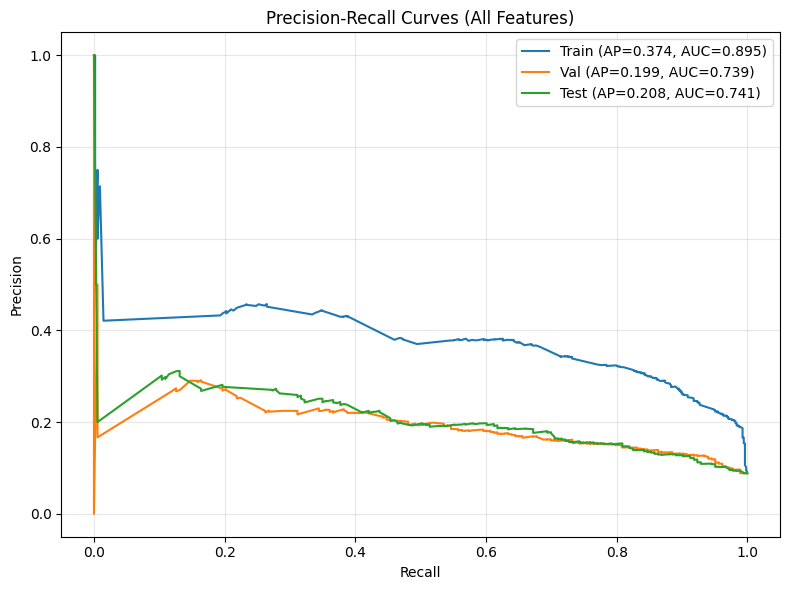

In [ ]:
# ── Precision-Recall Curves (all features) ───────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for preds, targets, name, auc_v in [
    (train_preds_all, y_train_all, 'Train', train_auc_all),
    (val_preds_all,   y_val_all,   'Val',   val_auc_all),
    (test_preds_all,  y_test_all,  'Test',  test_auc_all),
]:
    prec, rec, _ = precision_recall_curve(targets, preds)
    ap_v = average_precision_score(targets, preds)
    ax.plot(rec, prec, label=f'{name} (AP={ap_v:.3f}, AUC={auc_v:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (All Features)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── Summary: All Features vs Top-50 ──────────────────────────────
print('Comparison: Top-50 Features vs All Features')
print('=' * 70)
print(f'{"Metric":<22} {"Top-50":<22} {"All Features":<22}')
print(f'{"-"*66}')
print(f'{"Num features":<22} {len(available_features):<22} {len(all_feature_cols):<22}')
print(f'{"Best iteration":<22} {model.best_iteration:<22} {model_all.best_iteration:<22}')
print(f'{"Training time (s)":<22} {training_time:<22.2f} {training_time_all:<22.2f}')
print()
print(f'{"Split":<8} {"Metric":<16} {"Top-50":<14} {"All Features":<14}')
print(f'{"-"*52}')
for split, (auc50, ap50, t50, auca, apa, ta) in {
    'Train': (train_auc, train_ap, train_time, train_auc_all, train_ap_all, train_time_all),
    'Val':   (val_auc,   val_ap,   val_time,   val_auc_all,   val_ap_all,   val_time_all),
    'Test':  (test_auc,  test_ap,  test_time,  test_auc_all,  test_ap_all,  test_time_all),
}.items():
    print(f'{split:<8} {"ROC-AUC":<16} {auc50:<14.4f} {auca:<14.4f}')
    print(f'{"":8} {"Avg Precision":<16} {ap50:<14.4f} {apa:<14.4f}')
    print(f'{"":8} {"Score time (s)":<16} {t50:<14.4f} {ta:<14.4f}')

Comparison: Top-50 Features vs All Features
Metric                 Top-50                 All Features          
------------------------------------------------------------------
Num features           100                    217                   
Best iteration         2                      3                     
Training time (s)      0.94                   0.96                  

Split    Metric           Top-50         All Features  
----------------------------------------------------
Train    ROC-AUC          0.8618         0.8950        
         Avg Precision    0.2987         0.3742        
         Score time (s)   0.0000         0.0020        
Val      ROC-AUC          0.7063         0.7388        
         Avg Precision    0.1808         0.1990        
         Score time (s)   0.0000         0.0020        
Test     ROC-AUC          0.7176         0.7406        
         Avg Precision    0.1967         0.2085        
         Score time (s)   0.0020         0.0000        

## 8. Training vs Validation Loss Curves

A widening gap between train and val loss indicates **overfitting**.

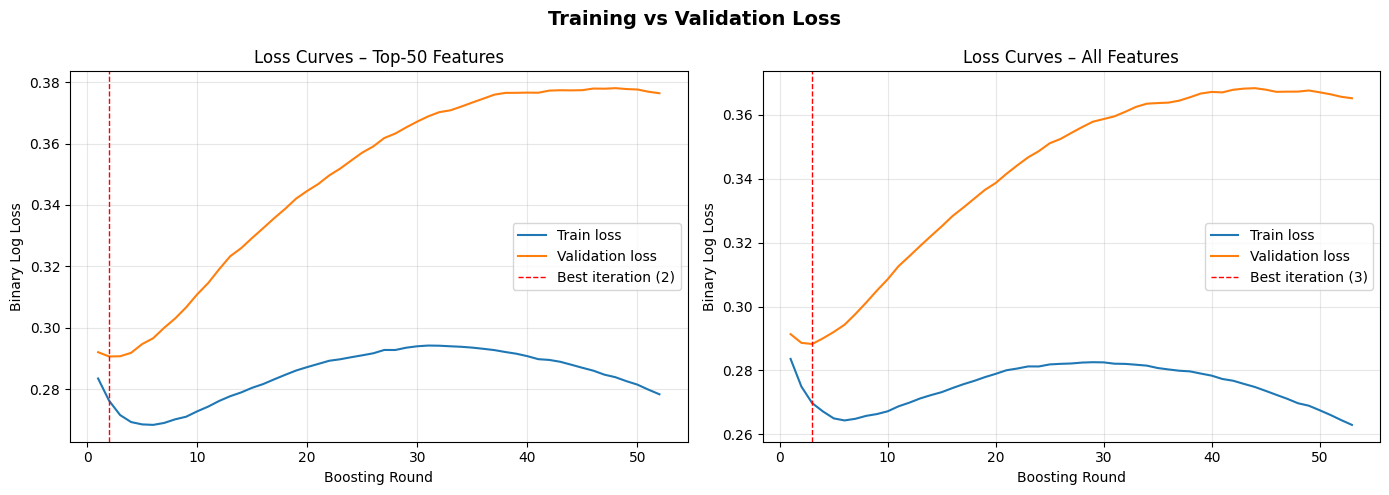

In [ ]:
# ── Training vs Validation Loss Curves ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, evals, title, best_iter in [
    (axes[0], evals_result,     'Top-50 Features', model.best_iteration),
    (axes[1], evals_result_all, 'All Features',    model_all.best_iteration),
]:
    train_loss = evals['train']['binary_logloss']
    val_loss   = evals['val']['binary_logloss']
    rounds     = range(1, len(train_loss) + 1)

    ax.plot(rounds, train_loss, label='Train loss',      linewidth=1.5)
    ax.plot(rounds, val_loss,   label='Validation loss', linewidth=1.5)
    ax.axvline(best_iter, color='red', linestyle='--', linewidth=1,
               label=f'Best iteration ({best_iter})')
    ax.set_xlabel('Boosting Round')
    ax.set_ylabel('Binary Log Loss')
    ax.set_title(f'Loss Curves – {title}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 9. Regularized Model (Overfitting Fix)

Early overfitting is caused by trees that are too complex. Key changes vs the baseline:

| Parameter | Baseline | Regularized | Why |
|---|---|---|---|
| `num_leaves` | 31 | **15** | Fewer leaves → simpler trees |
| `max_depth` | -1 (unlimited) | **5** | Hard cap on tree depth |
| `min_child_samples` | 20 | **100** | Each leaf needs more data |
| `subsample` | 0.8 | **0.6** | More randomness per tree |
| `colsample_bytree` | 0.8 | **0.6** | Sample fewer features per tree |
| `reg_alpha` | 0.1 | **1.0** | L1 sparsity regularization |
| `reg_lambda` | 0.1 | **5.0** | L2 weight regularization |
| `min_split_gain` | 0 | **0.05** | Require meaningful splits only |
| `learning_rate` | 0.05 | **0.02** | Slower learning, more rounds |

In [ ]:
# ── Regularized LightGBM (Top-50 features) ───────────────────────
params_reg = {
    'objective':          'binary',
    'metric':             ['auc', 'binary_logloss'],
    'boosting_type':      'gbdt',
    'scale_pos_weight':   scale_pos_weight,

    # ── tree complexity (main overfitting levers) ──
    'num_leaves':         15,     # was 31
    'max_depth':          5,      # was -1 (unlimited)
    'min_child_samples':  100,    # was 20

    # ── stochasticity ──
    'subsample':          0.6,    # was 0.8
    'colsample_bytree':   0.6,    # was 0.8

    # ── regularization ──
    'reg_alpha':          1.0,    # was 0.1
    'reg_lambda':         5.0,    # was 0.1
    'min_split_gain':     0.05,   # was 0 (no threshold)

    # ── learning ──
    'learning_rate':      0.02,   # was 0.05 (slower + more rounds)
    'verbose':            -1,
    'seed':               42,
}

evals_result_reg = {}

print('Training regularized LightGBM...')
t0_reg = time.time()

model_reg = lgb.train(
    params_reg,
    train_data,                     # same split as baseline
    num_boost_round=2000,           # more rounds at lower LR
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True),
        lgb.log_evaluation(period=100),
        lgb.record_evaluation(evals_result_reg),
    ],
)

training_time_reg = time.time() - t0_reg
print(f'\nDone in {training_time_reg:.2f}s  |  best iteration: {model_reg.best_iteration}')
print(f'Best val AUC: {model_reg.best_score["val"]["auc"]:.4f}')


Training regularized LightGBM...
Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.902796	train's binary_logloss: 0.397465	val's auc: 0.778921	val's binary_logloss: 0.439524
Early stopping, best iteration is:
[5]	train's auc: 0.820092	train's binary_logloss: 0.28617	val's auc: 0.74991	val's binary_logloss: 0.290962

Done in 1.46s  |  best iteration: 5
Best val AUC: 0.7499


In [ ]:
# ── Evaluate regularized model ────────────────────────────────────
train_preds_reg, train_auc_reg, train_ap_reg, train_time_reg = evaluate(
    model_reg, X_train, y_train, 'TRAIN (regularized)')
val_preds_reg, val_auc_reg, val_ap_reg, val_time_reg = evaluate(
    model_reg, X_val, y_val, 'VALIDATION (regularized)')
test_preds_reg, test_auc_reg, test_ap_reg, test_time_reg = evaluate(
    model_reg, X_test, y_test, 'TEST (regularized)')

print('\nBaseline vs Regularized (Top-50)')
print('=' * 58)
print(f'{"Split":<8} {"Metric":<18} {"Baseline":<14} {"Regularized":<14}')
print(f'{"-"*58}')
for split_name, (auc_b, auc_r) in {
    'Train': (train_auc,     train_auc_reg),
    'Val':   (val_auc,       val_auc_reg),
    'Test':  (test_auc,      test_auc_reg),
}.items():
    print(f'{split_name:<8} {"ROC-AUC":<18} {auc_b:<14.4f} {auc_r:<14.4f}')



TRAIN (regularized) Results
ROC-AUC: 0.8201
Average Precision: 0.2624
Scoring Time: 0.0018 seconds

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.91      1.00      0.95      5642
          DQ       0.00      0.00      0.00       548

    accuracy                           0.91      6190
   macro avg       0.46      0.50      0.48      6190
weighted avg       0.83      0.91      0.87      6190

Confusion Matrix:
[[5642    0]
 [ 548    0]]

VALIDATION (regularized) Results
ROC-AUC: 0.7499
Average Precision: 0.1930
Scoring Time: 0.0000 seconds

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.91      1.00      0.95      1880
          DQ       0.00      0.00      0.00       183

    accuracy                           0.91      2063
   macro avg       0.46      0.50      0.48      2063
weighted avg       0.83      0.91      0.87      2063

Confusion Matrix:
[[1880    0]
 [ 183    0]]

TE

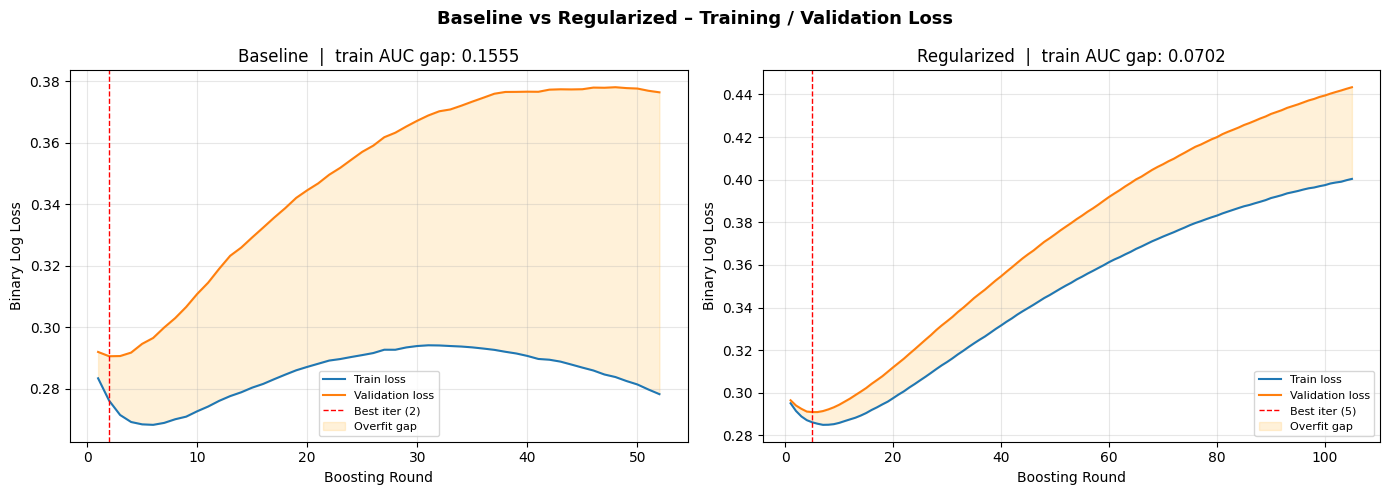

In [ ]:
# ── Loss curves: Baseline vs Regularized ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, evals, title, best_iter in [
    (axes[0], evals_result,     'Baseline',     model.best_iteration),
    (axes[1], evals_result_reg, 'Regularized',  model_reg.best_iteration),
]:
    train_loss = evals['train']['binary_logloss']
    val_loss   = evals['val']['binary_logloss']
    rounds     = range(1, len(train_loss) + 1)

    ax.plot(rounds, train_loss, label='Train loss',      linewidth=1.5)
    ax.plot(rounds, val_loss,   label='Validation loss', linewidth=1.5)
    ax.axvline(best_iter, color='red', linestyle='--', linewidth=1,
               label=f'Best iter ({best_iter})')

    # Shade the gap between train and val to make overfitting visible
    ax.fill_between(rounds, train_loss, val_loss,
                    where=[v > t for t, v in zip(train_loss, val_loss)],
                    alpha=0.15, color='orange', label='Overfit gap')

    ax.set_xlabel('Boosting Round')
    ax.set_ylabel('Binary Log Loss')
    ax.set_title(f'{title}  |  train AUC gap: '
                 f'{(train_auc if title=="Baseline" else train_auc_reg) - (val_auc if title=="Baseline" else val_auc_reg):.4f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Baseline vs Regularized – Training / Validation Loss', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
